РАСЧЕТ РАЗМЕРА ТРАФИКА

In [2]:
from statsmodels.stats.power import zt_ind_solve_power
from statsmodels.stats.proportion import proportion_effectsize

# Мои параметры
current_conversion = 0.05   # 5% текущая конверсия
expected_conversion = 0.09  # 9% ожидаемая конверсия
alpha = 0.05   # риск ошибки I рода (5%)
power = 0.80    # мощность теста (80%)

# Рассчет размер эффекта
effect_size = proportion_effectsize(current_conversion, expected_conversion)

# Рассчитываем необходимый размер выборки на группу
sample_size_per_group = zt_ind_solve_power(
    effect_size=effect_size,
    alpha=alpha,
    power=power,
    alternative='two-sided'
)

print(f"Необходимый размер выборки на группу: {int(sample_size_per_group)} пользователей")
print(f"Всего нужно пользователей: {int(sample_size_per_group * 2)}")
print(f"При дневном трафике 1000 человек потребуется дней: {int(sample_size_per_group * 2 / 1000)}")

Необходимый размер выборки на группу: 625 пользователей
Всего нужно пользователей: 1251
При дневном трафике 1000 человек потребуется дней: 1


РАСЧЕТ Количества дней для наьора выборки при трафике 150 человек


In [4]:
# Мои реальные цифры
daily_traffic = 150 # мой трафик

# Пользователей в день на одну группу (при 50/50 сплитовании)
daily_per_group = daily_traffic / 2  # 75 человек в день на группу

# Сколько дней нужно для набора 625 человек в группу
days_needed = sample_size_per_group / daily_per_group

print(f"Мой дневной трафик: {daily_traffic} человек")
print(f"Из них в группе A: {daily_per_group} человек/день")
print(f"Из них в группе B: {daily_per_group} человек/день")
print(f"\n Нужно дней для набора 625 человек в группу: {days_needed:.1f} дней")
print(f"   (округляем до {int(days_needed) + 1} дней)")

Мой дневной трафик: 150 человек
Из них в группе A: 75.0 человек/день
Из них в группе B: 75.0 человек/день

 Нужно дней для набора 625 человек в группу: 8.3 дней
   (округляем до 9 дней)


In [5]:
# Полный расчет с моими  цифрами
from statsmodels.stats.power import zt_ind_solve_power
from statsmodels.stats.proportion import proportion_effectsize

current_conversion = 0.05
expected_conversion = 0.09
alpha = 0.05
power = 0.80
daily_traffic = 150

# Расчет размера выборки
effect_size = proportion_effectsize(current_conversion, expected_conversion)
sample_size_per_group = zt_ind_solve_power(
    effect_size=effect_size,
    alpha=alpha,
    power=power,
    alternative='two-sided'
)

print("📊 РАСЧЕТЫ ДЛЯ ТВОЕГО МАГАЗИНА РУЧЕК")
print("=" * 50)
print(f"Текущая конверсия: {current_conversion:.0%}")
print(f"Ожидаемая конверсия: {expected_conversion:.0%}")
print(f"Нужно пользователей в группе: {int(sample_size_per_group)}")
print(f"Всего пользователей: {int(sample_size_per_group * 2)}")
print(f"Мой дневной трафик: {daily_traffic} чел/день")
print(f"Дней при 50/50 сплитовании: {(sample_size_per_group * 2 / daily_traffic):.1f} дней")
print(f"Рекомендуемая длительность: {int(sample_size_per_group * 2 / daily_traffic) + 1} дней")

📊 РАСЧЕТЫ ДЛЯ ТВОЕГО МАГАЗИНА РУЧЕК
Текущая конверсия: 5%
Ожидаемая конверсия: 9%
Нужно пользователей в группе: 625
Всего пользователей: 1251
Мой дневной трафик: 150 чел/день
Дней при 50/50 сплитовании: 8.3 дней
Рекомендуемая длительность: 9 дней


ГЕНЕРАЦИЯ ДАННЫХ ДЛЯ ПЕРВОГО ДНЯ




In [6]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

np.random.seed(42)  # для воспроизводимости
random.seed(42)

# Параметры первого дня
test_day = 1
test_date = datetime(2026, 4, 20)  # первый день теста
daily_traffic = 150  # 150 человек в день

# Конверсии по группам
conversion_a = 0.05  # 5% - старый лендинг
conversion_b = 0.09  # 9% - новый лендинг (мы надеемся)

# Создаем данные для 150 пользователей
users = []
for i in range(1, daily_traffic + 1):
    user_id = 1000 + i  # уникальный ID
    
    # Случайное распределение в группы A или B (50/50)
    group = 'A' if random.random() < 0.5 else 'B'
    
    # Выбираем конверсию в зависимости от группы
    if group == 'A':
        purchase_prob = conversion_a
    else:
        purchase_prob = conversion_b
    
    # Купил или нет?
    purchase_flag = 1 if random.random() < purchase_prob else 0
    
    # Генерируем сумму покупки (если купил)
    if purchase_flag == 1:
        # Средний чек ~500 руб, разброс 200-1000
        revenue = round(random.uniform(200, 1000), 2)
    else:
        revenue = 0
    
    # Количество просмотренных страниц
    # Чем дольше на сайте, тем больше просмотров
    if purchase_flag == 1:
        page_views = random.randint(5, 15)  # купившие смотрят больше
    else:
        page_views = random.randint(1, 8)   # не купившие уходят быстрее
    
    # Длительность сессии (секунды)
    # Связана с количеством просмотров
    session_duration_sec = page_views * random.randint(15, 45)
    
    # Генерируем случайное время визита в течение дня
    hour = random.randint(9, 21)  # с 9 утра до 9 вечера
    minute = random.randint(0, 59)
    second = random.randint(0, 59)
    visited_at = test_date.replace(hour=hour, minute=minute, second=second)
    
    users.append({
        'user_id': user_id,
        'group_name': group,
        'visit_date': test_date.date(),
        'visited_at': visited_at,
        'purchase_flag': purchase_flag,
        'revenue': revenue,
        'page_views': page_views,
        'session_duration_sec': session_duration_sec
    })

# Создаем DataFrame
df_day1 = pd.DataFrame(users)

print(" ДАННЫЕ ПЕРВОГО ДНЯ ТЕСТА")
print("=" * 50)
print(f"Дата: {test_date.date()}")
print(f"Всего посетителей: {len(df_day1)}")
print(f"\nРаспределение по группам:")
print(df_day1['group_name'].value_counts())
print(f"\nКонверсия в день 1:")
for group in ['A', 'B']:
    group_data = df_day1[df_day1['group_name'] == group]
    conv = group_data['purchase_flag'].mean() * 100
    print(f"  Группа {group}: {len(group_data)} чел, конверсия {conv:.1f}%")

# Сохраняем в CSV для импорта в PostgreSQL
df_day1.to_csv('pen_shop_day1.csv', index=False)
print(f"\n✅ Файл 'pen_shop_day1.csv' сохранён для импорта в PostgreSQL")

 ДАННЫЕ ПЕРВОГО ДНЯ ТЕСТА
Дата: 2026-04-20
Всего посетителей: 150

Распределение по группам:
group_name
A    79
B    71
Name: count, dtype: int64

Конверсия в день 1:
  Группа A: 79 чел, конверсия 5.1%
  Группа B: 71 чел, конверсия 9.9%

✅ Файл 'pen_shop_day1.csv' сохранён для импорта в PostgreSQL


ВИЗУАЛИЗАЦИЯ 1 ДНЯ

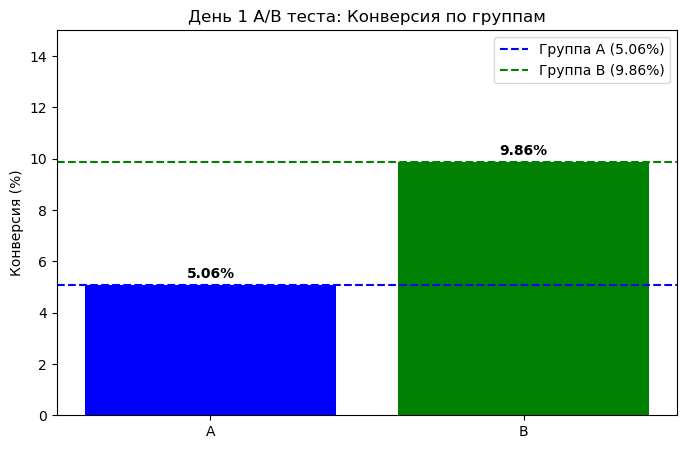


⚠️ ВАЖНО: Это только ДЕНЬ 1! Не делать выводов!
До завершения теста осталось дней: 8 дней


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Твои данные дня 1
data_day1 = pd.DataFrame({
    'group': ['A', 'B'],
    'visitors': [79, 71],
    'purchases': [4, 7],
    'conversion': [5.06, 9.86]
})

# Построим график
plt.figure(figsize=(8, 5))
bars = plt.bar(data_day1['group'], data_day1['conversion'], color=['blue', 'green'])
plt.axhline(y=5.06, color='blue', linestyle='--', label='Группа A (5.06%)')
plt.axhline(y=9.86, color='green', linestyle='--', label='Группа B (9.86%)')
plt.ylabel('Конверсия (%)')
plt.title('День 1 A/B теста: Конверсия по группам')
plt.legend()
plt.ylim(0, 15)

# Добавим подписи на столбцах
for bar, conv in zip(bars, data_day1['conversion']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, 
             f'{conv}%', ha='center', fontweight='bold')

plt.show()

print("\n⚠️ ВАЖНО: Это только ДЕНЬ 1! Не делать выводов!")
print(f"До завершения теста осталось дней: {9 - 1} дней")